# Appliance Energy Prediction — Feature Engineering

In [2]:
import pandas as pd
import numpy as np

train_df = pd.read_csv('../data/processed/train_scaled.csv', parse_dates=['date'])
test_df = pd.read_csv('../data/processed/test_scaled.csv', parse_dates=['date'])

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (15788, 29)
Test shape: (3947, 29)


## 1. Time-Based Features

In [3]:
def add_time_features(df):
    df = df.copy()
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek  # Monday=0, Sunday=6
    df['month'] = df['date'].dt.month
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    # NSM = seconds since midnight (as mentioned in the guideline)
    df['NSM'] = df['date'].dt.hour * 3600 + df['date'].dt.minute * 60 + df['date'].dt.second
    return df

train_df = add_time_features(train_df)
test_df = add_time_features(test_df)

train_df[['date', 'hour', 'day_of_week', 'month', 'is_weekend', 'NSM']].head()

,date,hour,day_of_week,month,is_weekend,NSM
0,2016-01-11 17:00:00,17,0,1,0,61200
1,2016-01-11 17:10:00,17,0,1,0,61800
2,2016-01-11 17:20:00,17,0,1,0,62400
3,2016-01-11 17:30:00,17,0,1,0,63000
4,2016-01-11 17:40:00,17,0,1,0,63600


## 2. Rolling Averages

In [4]:
def add_rolling_features(df):
    df = df.copy()
    # 1-hour window = 6 rows (since data is at 10-min intervals), 3-hour window = 18 rows
    df['Appliances_roll_1h'] = df['Appliances'].rolling(window=6, min_periods=1).mean()
    df['Appliances_roll_3h'] = df['Appliances'].rolling(window=18, min_periods=1).mean()
    df['T_out_roll_1h'] = df['T_out'].rolling(window=6, min_periods=1).mean()
    return df

train_df = add_rolling_features(train_df)
test_df = add_rolling_features(test_df)

train_df[['date', 'Appliances', 'Appliances_roll_1h', 'Appliances_roll_3h', 'T_out_roll_1h']].head(10)

,date,Appliances,Appliances_roll_1h,Appliances_roll_3h,T_out_roll_1h
0,2016-01-11 17:00:00,0.046729,0.046729,0.046729,0.372990
1,2016-01-11 17:10:00,0.046729,0.046729,0.046729,0.371115
2,2016-01-11 17:20:00,0.037383,0.043614,0.043614,0.369239
3,2016-01-11 17:30:00,0.037383,0.042056,0.042056,0.367363
4,2016-01-11 17:40:00,0.046729,0.042991,0.042991,0.365488
5,2016-01-11 17:50:00,0.037383,0.042056,0.042056,0.363612
6,2016-01-11 18:00:00,0.046729,0.042056,0.042724,0.359861
7,2016-01-11 18:10:00,0.046729,0.042056,0.043224,0.356824
8,2016-01-11 18:20:00,0.046729,0.043614,0.043614,0.354502
9,2016-01-11 18:30:00,0.056075,0.046729,0.044860,0.352894


## 3. Lagged Features

In [5]:
def add_lag_features(df):
    df = df.copy()
    # Lag periods: 10 min ago (1 step), 30 min ago (3 steps), 1 hour ago (6 steps)
    df['Appliances_lag_10min'] = df['Appliances'].shift(1)
    df['Appliances_lag_30min'] = df['Appliances'].shift(3)
    df['Appliances_lag_1h'] = df['Appliances'].shift(6)
    return df

train_df = add_lag_features(train_df)
test_df = add_lag_features(test_df)

train_df[['date', 'Appliances', 'Appliances_lag_10min', 'Appliances_lag_30min', 'Appliances_lag_1h']].head(10)

,date,Appliances,Appliances_lag_10min,Appliances_lag_30min,Appliances_lag_1h
0,2016-01-11 17:00:00,0.046729,NaN,NaN,NaN
1,2016-01-11 17:10:00,0.046729,0.046729,NaN,NaN
2,2016-01-11 17:20:00,0.037383,0.046729,NaN,NaN
3,2016-01-11 17:30:00,0.037383,0.037383,0.046729,NaN
4,2016-01-11 17:40:00,0.046729,0.037383,0.046729,NaN
5,2016-01-11 17:50:00,0.037383,0.046729,0.037383,NaN
6,2016-01-11 18:00:00,0.046729,0.037383,0.037383,0.046729
7,2016-01-11 18:10:00,0.046729,0.046729,0.046729,0.046729
8,2016-01-11 18:20:00,0.046729,0.046729,0.037383,0.037383
9,2016-01-11 18:30:00,0.056075,0.046729,0.046729,0.037383


## 4. Autocorrelation Analysis

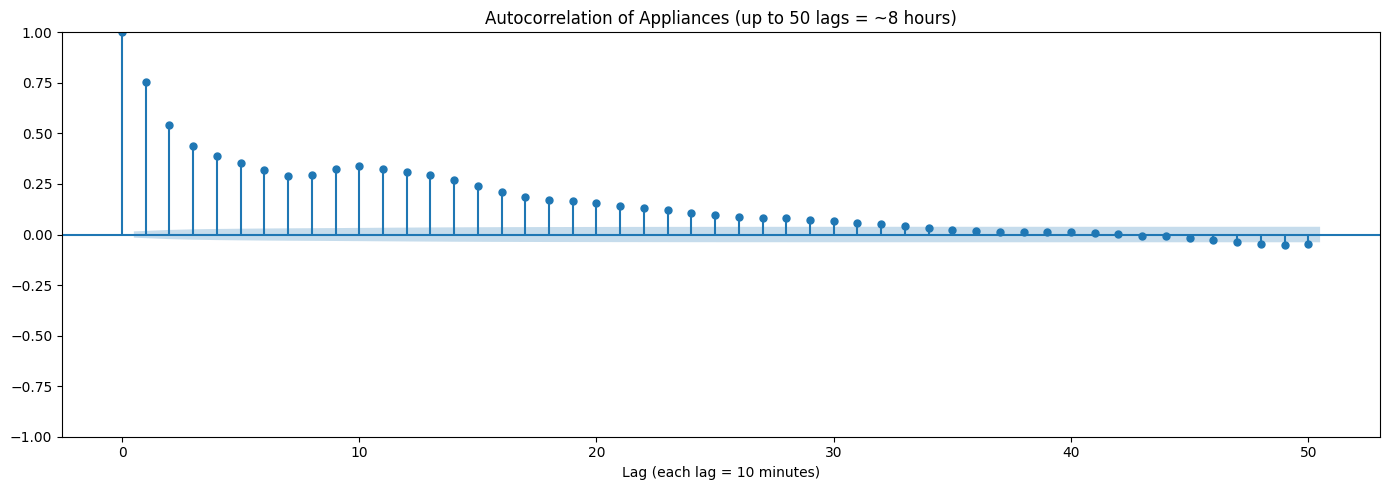

In [12]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
plot_acf(train_df['Appliances'].dropna(), lags=50, ax=ax)
plt.title('Autocorrelation of Appliances (up to 50 lags = ~8 hours)')
plt.xlabel('Lag (each lag = 10 minutes)')
plt.tight_layout()
plt.savefig('../reports/figures/04_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Interaction Features

In [8]:
def add_interaction_features(df):
    df = df.copy()
    # Temperature-humidity interaction 
    df['T1_RH1_interaction'] = df['T1'] * df['RH_1']
    df['Tout_RHout_interaction'] = df['T_out'] * df['RH_out']
    return df

train_df = add_interaction_features(train_df)
test_df = add_interaction_features(test_df)

train_df[['T1', 'RH_1', 'T1_RH1_interaction', 'T_out', 'RH_out', 'Tout_RHout_interaction']].head()

,T1,RH_1,T1_RH1_interaction,T_out,RH_out,Tout_RHout_interaction
0,0.32735,0.566187,0.185341,0.372990,0.894737,0.333728
1,0.32735,0.541326,0.177203,0.369239,0.894737,0.330372
2,0.32735,0.530502,0.173660,0.365488,0.894737,0.327015
3,0.32735,0.524080,0.171557,0.361736,0.894737,0.323659
4,0.32735,0.531419,0.173960,0.357985,0.894737,0.320302


## 6. Cleanup — Drop Noise Columns & Handle NaN Rows

In [9]:
# Drop rv1, rv2 (confirmed as random noise, near-zero correlation with target)
train_df = train_df.drop(columns=['rv1', 'rv2'])
test_df = test_df.drop(columns=['rv1', 'rv2'])

# Drop rows with NaN caused by lag/rolling features (only affects the first few rows)
print("Before dropping NaN - Train:", train_df.shape, "Test:", test_df.shape)
train_df = train_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)
print("After dropping NaN - Train:", train_df.shape, "Test:", test_df.shape)

Before dropping NaN - Train: (15788, 40) Test: (3947, 40)
After dropping NaN - Train: (15782, 40) Test: (3941, 40)


## 7. Feature Selection (Random Forest Importance)

                 feature  importance
33  Appliances_lag_10min    0.545273
30    Appliances_roll_1h    0.148199
34  Appliances_lag_30min    0.056190
35     Appliances_lag_1h    0.026917
31    Appliances_roll_3h    0.014536
29                   NSM    0.011999
2                   RH_1    0.009845
7                     T4    0.009727
20           Press_mm_hg    0.009021
15                    T8    0.008708
11                    T6    0.008157
10                  RH_5    0.008144
36    T1_RH1_interaction    0.008114
5                     T3    0.008108
21                RH_out    0.007995
4                   RH_2    0.007951
12                  RH_6    0.007455
22             Windspeed    0.007307
23            Visibility    0.007092
18                  RH_9    0.006818


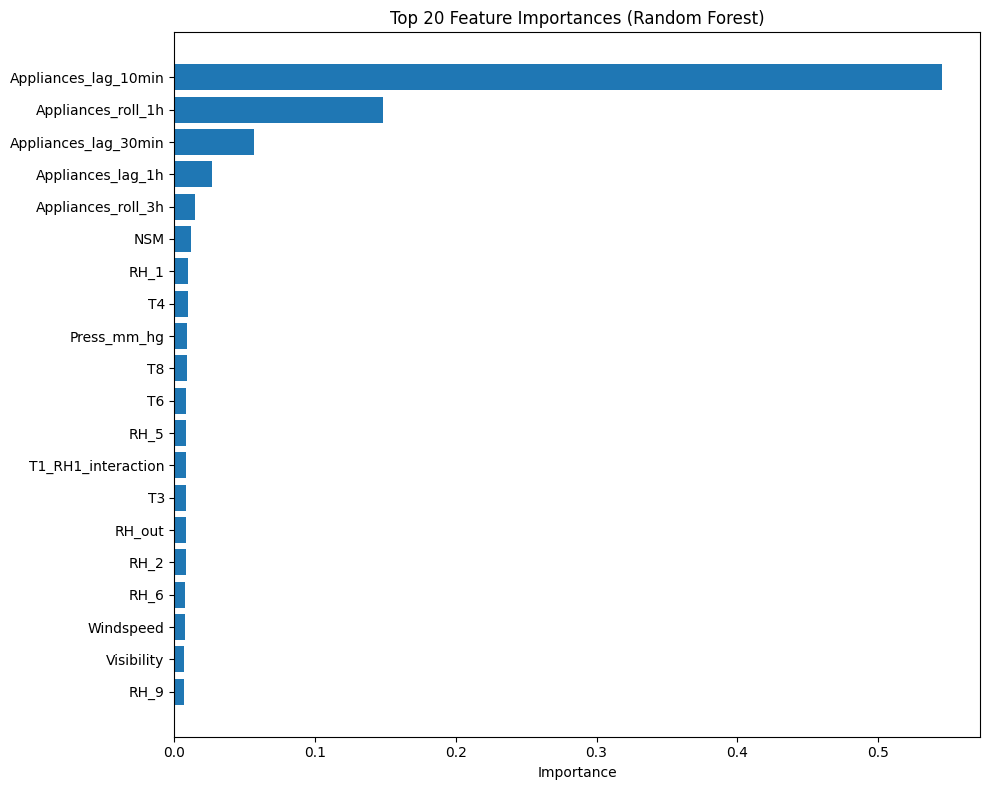

In [13]:
from sklearn.ensemble import RandomForestRegressor

feature_cols = [col for col in train_df.columns if col not in ['date', 'Appliances']]

X_temp = train_df[feature_cols]
y_temp = train_df['Appliances']

rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_temp, y_temp)

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.head(20))

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'][:20][::-1], importance_df['importance'][:20][::-1])
plt.title('Top 20 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../reports/figures/05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Final Feature Selection & Save

In [11]:
# Select top features: engineered features + a reasonable set of raw environmental features
final_features = [
    'Appliances_lag_10min', 'Appliances_roll_1h', 'Appliances_lag_30min',
    'Appliances_lag_1h', 'Appliances_roll_3h', 'NSM', 'RH_1', 'T4',
    'Press_mm_hg', 'T8', 'T6', 'RH_5', 'T1_RH1_interaction', 'T3',
    'RH_out', 'RH_2', 'RH_6', 'Windspeed', 'Visibility', 'RH_9',
    'lights', 'hour', 'day_of_week', 'is_weekend'
]

train_final = train_df[['date', 'Appliances'] + final_features]
test_final = test_df[['date', 'Appliances'] + final_features]

print("Final train shape:", train_final.shape)
print("Final test shape:", test_final.shape)

train_final.to_csv('../data/processed/train_final.csv', index=False)
test_final.to_csv('../data/processed/test_final.csv', index=False)
print("Saved final feature sets.")

Final train shape: (15782, 26)
Final test shape: (3941, 26)
Saved final feature sets.
